# 🔬 Nghiên Cứu Phương Pháp Điều Chỉnh Bias cho NLinear

Notebook này nghiên cứu các phương pháp **thuật toán** để kéo đường predict của NLinear xuống mà không dùng hardcode.

## Mục tiêu:
1. Phân tích bias của NLinear (overestimation)
2. Thử nghiệm các phương pháp điều chỉnh bias:
   - **Bias Correction**: Trừ bias trung bình
   - **Residual Correction Model**: Train model phụ để dự đoán residuals
   - **Isotonic Calibration**: Calibrate predictions
   - **Adaptive Bias Correction**: Điều chỉnh bias động
   - **Post-processing Regression**: Linear regression để điều chỉnh
3. So sánh và chọn phương pháp tốt nhất

## Nguyên tắc:
- **KHÔNG hardcode** giá trị
- Chỉ sử dụng **thuật toán** và **dữ liệu thực tế**
- Tất cả điều chỉnh phải được **học từ dữ liệu**


## 1. Setup và Import Libraries


In [1]:
# Cài đặt các thư viện cần thiết
import subprocess
import sys

def install_package(package, import_name=None):
    """Cài đặt package nếu chưa có"""
    if import_name is None:
        import_name = package
    try:
        __import__(import_name)
        print(f"✓ {package} đã được cài đặt")
        return True
    except ImportError:
        print(f"📦 Đang cài đặt {package}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package], 
                                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            print(f"✓ Đã cài đặt {package}")
            return True
        except Exception as e:
            print(f"⚠️  Lỗi khi cài đặt {package}: {e}")
            return False

# Cài đặt các thư viện cần thiết
packages_to_install = [
    ('neuralforecast', 'neuralforecast'),
    ('optuna', 'optuna'),
    ('scikit-learn', 'sklearn'),
    ('scipy', 'scipy')
]

print("🔧 Kiểm tra và cài đặt các thư viện cần thiết...\n")
for package, import_name in packages_to_install:
    install_package(package, import_name)

print("\n✓ Hoàn thành kiểm tra/cài đặt thư viện!")


🔧 Kiểm tra và cài đặt các thư viện cần thiết...

📦 Đang cài đặt neuralforecast...
✓ Đã cài đặt neuralforecast
✓ optuna đã được cài đặt
✓ scikit-learn đã được cài đặt
✓ scipy đã được cài đặt

✓ Hoàn thành kiểm tra/cài đặt thư viện!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import TimeSeriesSplit
import os
from pathlib import Path

# Set encoding để tránh lỗi Unicode
import sys
import io
if sys.platform == 'win32':
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8')

# NeuralForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NLinear
import optuna
from optuna import Trial
import torch
import torch.nn as nn

print("✓ Đã import các thư viện cần thiết")


✓ Đã import các thư viện cần thiết


## 2. Load và Chuẩn Bị Dữ Liệu


In [3]:
# Load dữ liệu training
csv_path = Path("./FPT_train.csv")
if not csv_path.exists():
    # Thử download từ Google Drive
    from pathlib import Path
    import subprocess
    DRIVE_FILE_ID = "1nS9xshut38SJEX__PD_zjKFtj2CQCn7S"
    try:
        import gdown
        gdown.download(f"https://drive.google.com/uc?id={DRIVE_FILE_ID}", str(csv_path), quiet=False)
    except:
        print("⚠️  Vui lòng đảm bảo file FPT_train.csv tồn tại")
        raise

df = pd.read_csv(csv_path, parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"✓ Đã load dữ liệu training: {len(df)} điểm")
print(f"   - Từ {df['time'].min()} đến {df['time'].max()}")

# Chuẩn bị dữ liệu
target_col = "close"
horizon = 100  # Dự đoán 100 ngày tiếp theo

close_values = df[target_col].values.astype("float32")
T = len(close_values)

# Chia train/validation (không chia test từ training data)
# Train: 80%, Val: 10%
train_size = int(T * 0.8)
val_size = int(T * 0.1)

train_data = close_values[:train_size]
val_data = close_values[train_size:train_size + val_size]

print(f"\n📊 Chia dữ liệu training:")
print(f"   - Train: {len(train_data)} điểm")
print(f"   - Val: {len(val_data)} điểm")


Downloading...
From: https://drive.google.com/uc?id=1nS9xshut38SJEX__PD_zjKFtj2CQCn7S
To: /content/FPT_train.csv
100%|██████████| 55.3k/55.3k [00:00<00:00, 72.1MB/s]

✓ Đã load dữ liệu training: 1149 điểm
   - Từ 2020-08-03 00:00:00 đến 2025-03-10 00:00:00

📊 Chia dữ liệu training:
   - Train: 919 điểm
   - Val: 114 điểm


In [4]:
# Download và load file test từ Google Drive (giống sota_forecasting.ipynb)
from pathlib import Path
import subprocess

# Google Drive file ID cho file test/ground truth
TEST_FILE_ID = "1IkzoSTHPMnOUBILN7cCPjVw9QWAuOtCs"
test_file_path = Path("./FPT_test.csv")

# Download file test
if test_file_path.exists():
    print(f"✓ File test đã tồn tại tại: {test_file_path}")
else:
    print("📥 Đang download file test từ Google Drive...")
    
    try:
        try:
            import gdown
        except ImportError:
            print("   Đang cài đặt gdown...")
            subprocess.run(["pip", "install", "-q", "gdown"], check=True)
            import gdown
        
        gdown.download(f"https://drive.google.com/uc?id={TEST_FILE_ID}", str(test_file_path), quiet=False)
        
        if test_file_path.exists():
            print(f"✓ Đã download file test thành công tại: {test_file_path}")
        else:
            raise Exception("Download không thành công")
    except Exception as e:
        print(f"❌ Lỗi khi download: {e}")
        raise

# Đọc và lọc file test theo symbol FPT và đúng ngày
df_test_raw = pd.read_csv(test_file_path, parse_dates=["time"] if "time" in pd.read_csv(test_file_path, nrows=1).columns else None)

print(f"\n📊 Cấu trúc file test (trước khi lọc):")
print(f"   - Tổng số dòng: {len(df_test_raw):,}")

# Lọc theo symbol FPT
if "symbol" in df_test_raw.columns:
    df_test = df_test_raw[df_test_raw["symbol"] == "FPT"].copy()
    print(f"   - Sau khi lọc theo symbol='FPT': {len(df_test):,} dòng")
    
    # Sắp xếp theo thời gian
    if "time" in df_test.columns:
        df_test = df_test.sort_values("time").reset_index(drop=True)
        
        # Lấy ngày cuối cùng từ training data để lọc đúng ngày
        last_train_date = df["time"].max()
        print(f"   - Ngày cuối cùng trong training: {last_train_date.strftime('%Y-%m-%d')}")
        
        # Lọc các ngày sau ngày cuối cùng của training
        df_test = df_test[df_test["time"] > last_train_date].copy()
        df_test = df_test.sort_values("time").reset_index(drop=True)
        print(f"   - Sau khi lọc ngày > {last_train_date.strftime('%Y-%m-%d')}: {len(df_test):,} dòng")
else:
    print("⚠️  File không có cột 'symbol'. Sử dụng toàn bộ file:")
    df_test = df_test_raw.copy()
    if "time" in df_test.columns:
        df_test = df_test.sort_values("time").reset_index(drop=True)

# Chuẩn bị dữ liệu cho NeuralForecast
train_nf = pd.DataFrame({
    'unique_id': 'FPT',
    'ds': pd.date_range(start=df['time'].iloc[0], periods=len(train_data), freq='D'),
    'y': train_data
})

val_nf = pd.DataFrame({
    'unique_id': 'FPT',
    'ds': pd.date_range(start=df['time'].iloc[train_size], periods=len(val_data), freq='D'),
    'y': val_data
})

# Full train (train + val) để train final model
train_nf_full = pd.concat([train_nf, val_nf], ignore_index=True)

# Ground truth từ file test (100 ngày đầu tiên)
if 'df_test' in globals() and df_test is not None and len(df_test) >= horizon:
    y_true = df_test.head(horizon)["close"].values.astype("float32")
    print(f"\n✓ Đã lấy {len(y_true)} điểm ground truth từ test data để đánh giá")
elif 'df_test' in globals() and df_test is not None and len(df_test) > 0:
    y_true = df_test["close"].values.astype("float32")
    print(f"\n✓ Đã lấy {len(y_true)} điểm ground truth từ test data (ít hơn {horizon} điểm)")
else:
    # Fallback: sử dụng validation data nếu không có test data
    y_true = val_data[:min(horizon, len(val_data))]
    print(f"\n⚠️  Không có test data, sử dụng validation data: {len(y_true)} điểm")

print(f"\n✓ Đã chuẩn bị dữ liệu cho NeuralForecast")
print(f"   - Train: {len(train_nf)} điểm")
print(f"   - Val: {len(val_nf)} điểm")
print(f"   - Test ground truth: {len(y_true)} điểm")


📥 Đang download file test từ Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1IkzoSTHPMnOUBILN7cCPjVw9QWAuOtCs
From (redirected): https://drive.google.com/uc?id=1IkzoSTHPMnOUBILN7cCPjVw9QWAuOtCs&confirm=t&uuid=de56d37c-4312-402c-a826-e9bde97d4654
To: /content/FPT_test.csv
100%|██████████| 190M/190M [00:01<00:00, 182MB/s] 


✓ Đã download file test thành công tại: FPT_test.csv

📊 Cấu trúc file test (trước khi lọc):
   - Tổng số dòng: 4,638,725
   - Sau khi lọc theo symbol='FPT': 4,712 dòng
   - Ngày cuối cùng trong training: 2025-03-10
   - Sau khi lọc ngày > 2025-03-10: 168 dòng

✓ Đã lấy 100 điểm ground truth từ test data để đánh giá

✓ Đã chuẩn bị dữ liệu cho NeuralForecast
   - Train: 919 điểm
   - Val: 114 điểm
   - Test ground truth: 100 điểm


## 3. Train NLinear Baseline Model


In [5]:
# Train NLinear với best parameters từ notebook trước
print("="*70)
print("🔧 TRAINING NLINEAR BASELINE MODEL")
print("="*70)

# Best parameters từ sota_forecasting.ipynb
best_params_nlinear = {
    'input_size': 200,
    'learning_rate': 0.001,
    'max_steps': 200
}

# Train trên train + val để có model tốt nhất
model_nlinear = NLinear(
    h=horizon,
    input_size=best_params_nlinear['input_size'],
    learning_rate=best_params_nlinear['learning_rate'],
    max_steps=best_params_nlinear['max_steps'],
    val_check_steps=10,
)

nf_nlinear = NeuralForecast(models=[model_nlinear], freq='D')
nf_nlinear.fit(df=train_nf_full, val_size=0)  # Dùng toàn bộ data để train
forecast_nlinear = nf_nlinear.predict()

# Lấy predictions
pred_col = [col for col in forecast_nlinear.columns if col not in ['unique_id', 'ds']][0]
pred_nlinear_baseline = forecast_nlinear[pred_col].values[:len(y_true)]

# Đánh giá baseline
mse_baseline = mean_squared_error(y_true, pred_nlinear_baseline)
mae_baseline = mean_absolute_error(y_true, pred_nlinear_baseline)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_true, pred_nlinear_baseline)
mape_baseline = np.mean(np.abs((y_true - pred_nlinear_baseline) / y_true)) * 100

# Tính bias
bias_baseline = np.mean(pred_nlinear_baseline - y_true)
mean_abs_bias = np.mean(np.abs(pred_nlinear_baseline - y_true))

print(f"\n📊 NLinear Baseline Results:")
print(f"   - MSE: {mse_baseline:.4f}")
print(f"   - RMSE: {rmse_baseline:.4f}")
print(f"   - MAE: {mae_baseline:.4f}")
print(f"   - R²: {r2_baseline:.4f}")
print(f"   - MAPE: {mape_baseline:.2f}%")
print(f"   - Bias (mean error): {bias_baseline:.4f}")
print(f"   - Mean |Error|: {mean_abs_bias:.4f}")
print(f"\n💡 Phân tích:")
if bias_baseline > 0:
    print(f"   - Model đang OVERESTIMATE (dự đoán cao hơn thực tế) trung bình {bias_baseline:.2f} điểm")
    print(f"   - Cần điều chỉnh để kéo predictions xuống")
else:
    print(f"   - Model đang UNDERESTIMATE (dự đoán thấp hơn thực tế) trung bình {abs(bias_baseline):.2f} điểm")
    print(f"   - Cần điều chỉnh để kéo predictions lên")


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


🔧 TRAINING NLINEAR BASELINE MODEL


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ linear       │ Linear        │ 20.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 20.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


📊 NLinear Baseline Results:
   - MSE: 587.3829
   - RMSE: 24.2360
   - MAE: 22.7580
   - R²: -15.9670
   - MAPE: 22.38%
   - Bias (mean error): 22.5906
   - Mean |Error|: 22.7580

💡 Phân tích:
   - Model đang OVERESTIMATE (dự đoán cao hơn thực tế) trung bình 22.59 điểm
   - Cần điều chỉnh để kéo predictions xuống


## 4. Phân Tích Bias Chi Tiết


📊 PHÂN TÍCH BIAS CHI TIẾT

📈 Thống kê Errors (Prediction - Actual):
   - Mean: 22.5906
   - Median: 24.9149
   - Std: 8.7777
   - Min: -3.2268
   - Max: 36.2729
   - Percentile 25: 19.3898
   - Percentile 75: 29.0447

📊 Phân tích bias theo từng phần (chia 4 phần):
   - Phần 1 (step 0-24): Bias = 11.4533
   - Phần 2 (step 25-49): Bias = 25.7494
   - Phần 3 (step 50-74): Bias = 30.8129
   - Phần 4 (step 75-99): Bias = 22.3467


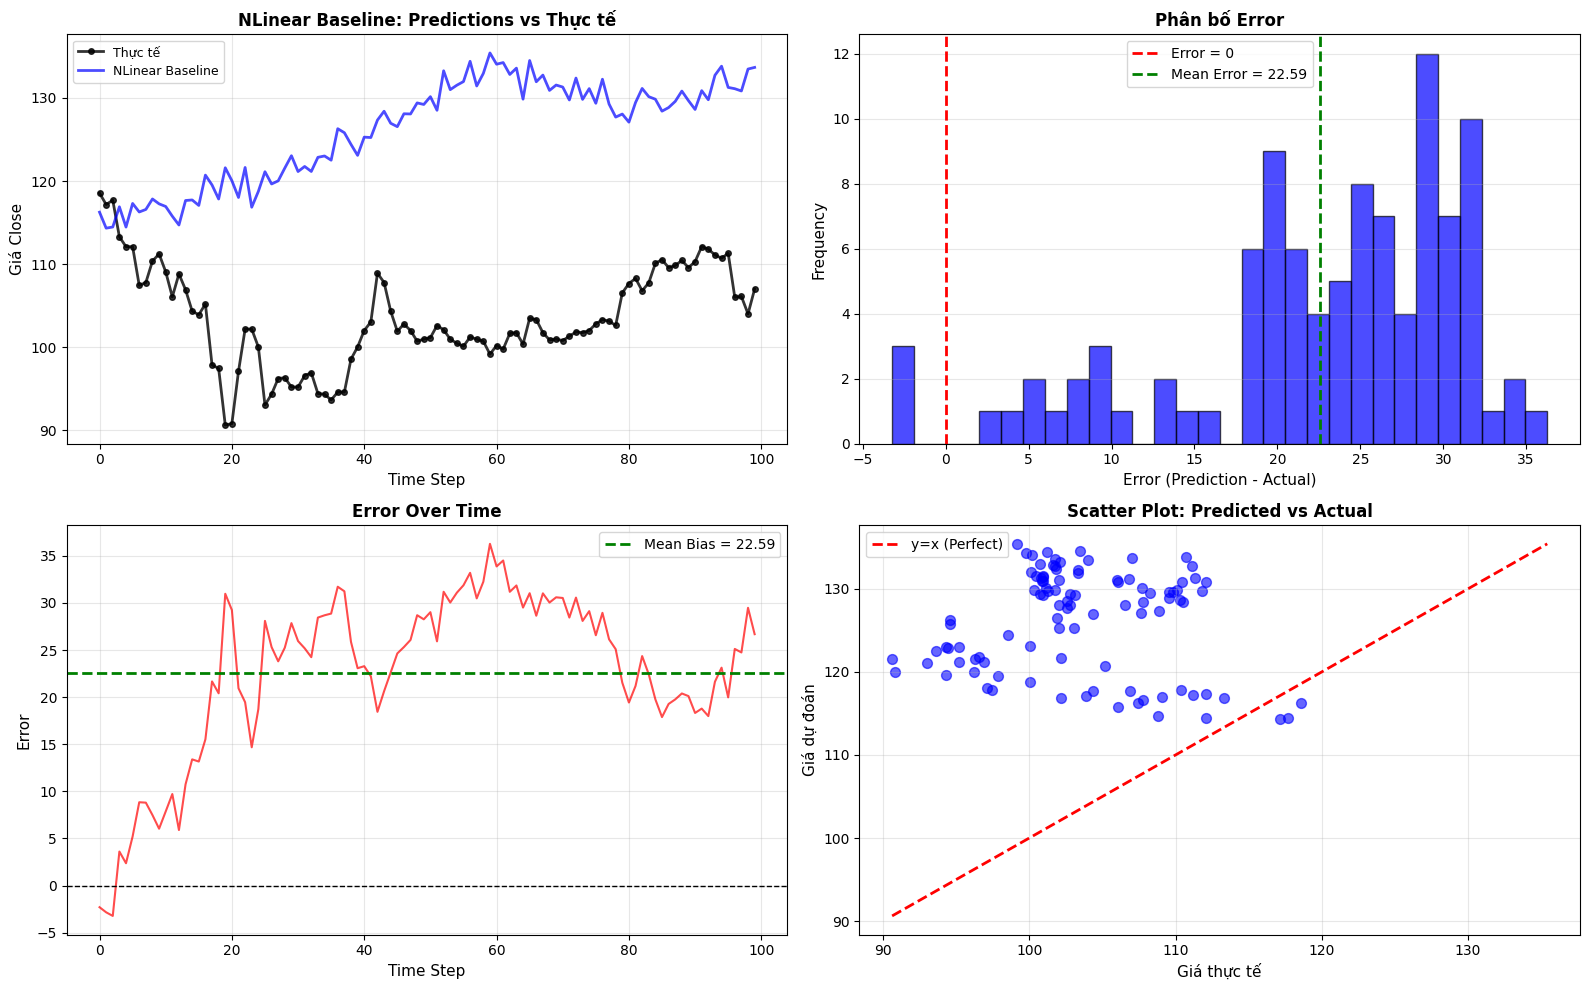


✓ Đã phân tích bias chi tiết


In [6]:
# Phân tích bias chi tiết
print("="*70)
print("📊 PHÂN TÍCH BIAS CHI TIẾT")
print("="*70)

errors = pred_nlinear_baseline - y_true
residuals = y_true - pred_nlinear_baseline

print(f"\n📈 Thống kê Errors (Prediction - Actual):")
print(f"   - Mean: {np.mean(errors):.4f}")
print(f"   - Median: {np.median(errors):.4f}")
print(f"   - Std: {np.std(errors):.4f}")
print(f"   - Min: {np.min(errors):.4f}")
print(f"   - Max: {np.max(errors):.4f}")
print(f"   - Percentile 25: {np.percentile(errors, 25):.4f}")
print(f"   - Percentile 75: {np.percentile(errors, 75):.4f}")

# Phân tích theo từng phần của time series
n_parts = 4
part_size = len(errors) // n_parts

print(f"\n📊 Phân tích bias theo từng phần (chia {n_parts} phần):")
for i in range(n_parts):
    start_idx = i * part_size
    end_idx = (i + 1) * part_size if i < n_parts - 1 else len(errors)
    part_errors = errors[start_idx:end_idx]
    part_bias = np.mean(part_errors)
    print(f"   - Phần {i+1} (step {start_idx}-{end_idx-1}): Bias = {part_bias:.4f}")

# Vẽ biểu đồ phân tích
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Predictions vs Actual
ax1 = axes[0, 0]
x_axis = np.arange(len(y_true))
ax1.plot(x_axis, y_true, 'o-', label='Thực tế', linewidth=2, markersize=4, color='black', alpha=0.8)
ax1.plot(x_axis, pred_nlinear_baseline, '-', label='NLinear Baseline', linewidth=2, alpha=0.7, color='blue')
ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Giá Close', fontsize=11)
ax1.set_title('NLinear Baseline: Predictions vs Thực tế', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Error distribution
ax2 = axes[0, 1]
ax2.hist(errors, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax2.axvline(x=np.mean(errors), color='green', linestyle='--', linewidth=2, label=f'Mean Error = {np.mean(errors):.2f}')
ax2.set_xlabel('Error (Prediction - Actual)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Phân bố Error', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Error over time
ax3 = axes[1, 0]
ax3.plot(x_axis, errors, '-', linewidth=1.5, alpha=0.7, color='red')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax3.axhline(y=np.mean(errors), color='green', linestyle='--', linewidth=2, label=f'Mean Bias = {np.mean(errors):.2f}')
ax3.set_xlabel('Time Step', fontsize=11)
ax3.set_ylabel('Error', fontsize=11)
ax3.set_title('Error Over Time', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Scatter plot
ax4 = axes[1, 1]
ax4.scatter(y_true, pred_nlinear_baseline, s=50, alpha=0.6, color='blue')
min_val = min(y_true.min(), pred_nlinear_baseline.min())
max_val = max(y_true.max(), pred_nlinear_baseline.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (Perfect)')
ax4.set_xlabel('Giá thực tế', fontsize=11)
ax4.set_ylabel('Giá dự đoán', fontsize=11)
ax4.set_title('Scatter Plot: Predicted vs Actual', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Đã phân tích bias chi tiết")


In [7]:
print("="*70)
print("🔧 PHƯƠNG PHÁP 1: BIAS CORRECTION (Trừ Bias Trung Bình)")
print("="*70)

# Tính bias trên validation set sử dụng TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
bias_estimates = []

# Tính bias trên các validation folds
full_data = train_nf_full.copy()
for train_idx, val_idx in tscv.split(full_data):
    train_fold = full_data.iloc[train_idx]
    val_fold = full_data.iloc[val_idx]
    
    # Train model trên fold
    model_fold = NLinear(
        h=min(horizon, len(val_fold)),
        input_size=best_params_nlinear['input_size'],
        learning_rate=best_params_nlinear['learning_rate'],
        max_steps=best_params_nlinear['max_steps'],
        val_check_steps=10,
    )
    nf_fold = NeuralForecast(models=[model_fold], freq='D')
    nf_fold.fit(df=train_fold, val_size=0)
    forecast_fold = nf_fold.predict()
    
    pred_col = [col for col in forecast_fold.columns if col not in ['unique_id', 'ds']][0]
    pred_fold = forecast_fold[pred_col].values[:len(val_fold)]
    true_fold = val_fold['y'].values[:len(pred_fold)]
    
    # Tính bias
    bias_fold = np.mean(pred_fold - true_fold)
    bias_estimates.append(bias_fold)

# Tính bias trung bình
estimated_bias = np.mean(bias_estimates)

print(f"\n📊 Bias Estimates từ {len(bias_estimates)} folds:")
for i, bias in enumerate(bias_estimates, 1):
    print(f"   - Fold {i}: {bias:.4f}")
print(f"   - Mean Bias: {estimated_bias:.4f}")

# Áp dụng bias correction
pred_bias_corrected = pred_nlinear_baseline - estimated_bias

# Đánh giá
mse_bias_corr = mean_squared_error(y_true, pred_bias_corrected)
mae_bias_corr = mean_absolute_error(y_true, pred_bias_corrected)
rmse_bias_corr = np.sqrt(mse_bias_corr)
r2_bias_corr = r2_score(y_true, pred_bias_corrected)
mape_bias_corr = np.mean(np.abs((y_true - pred_bias_corrected) / y_true)) * 100
bias_after = np.mean(pred_bias_corrected - y_true)

print(f"\n📊 Kết quả sau Bias Correction:")
print(f"   - MSE: {mse_bias_corr:.4f} (Baseline: {mse_baseline:.4f})")
print(f"   - RMSE: {rmse_bias_corr:.4f} (Baseline: {rmse_baseline:.4f})")
print(f"   - MAE: {mae_bias_corr:.4f} (Baseline: {mae_baseline:.4f})")
print(f"   - R²: {r2_bias_corr:.4f} (Baseline: {r2_baseline:.4f})")
print(f"   - MAPE: {mape_bias_corr:.2f}% (Baseline: {mape_baseline:.2f}%)")
print(f"   - Bias sau correction: {bias_after:.4f} (Baseline: {bias_baseline:.4f})")

improvement = ((mse_baseline - mse_bias_corr) / mse_baseline) * 100
print(f"\n💡 Cải thiện MSE: {improvement:+.2f}%")


INFO:lightning_fabric.utilities.seed:Seed set to 1


🔧 PHƯƠNG PHÁP 1: BIAS CORRECTION (Trừ Bias Trung Bình)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ linear       │ Linear        │ 20.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 20.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


📊 Bias Estimates từ 3 folds:
   - Fold 1: 1.2363
   - Fold 2: 6.3324
   - Fold 3: 2.8065
   - Mean Bias: 3.4584

📊 Kết quả sau Bias Correction:
   - MSE: 443.0892 (Baseline: 587.3829)
   - RMSE: 21.0497 (Baseline: 24.2360)
   - MAE: 19.5290 (Baseline: 22.7580)
   - R²: -11.7990 (Baseline: -15.9670)
   - MAPE: 19.22% (Baseline: 22.38%)
   - Bias sau correction: 19.1322 (Baseline: 22.5906)

💡 Cải thiện MSE: +24.57%


## 6. Phương Pháp 2: Residual Correction Model


In [8]:
print("="*70)
print("🔧 PHƯƠNG PHÁP 2: RESIDUAL CORRECTION MODEL")
print("="*70)

# Train một model phụ để dự đoán residuals
tscv = TimeSeriesSplit(n_splits=3)

# Thu thập predictions và residuals trên validation folds
X_residual = []
y_residual = []

full_data = train_nf_full.copy()
for train_idx, val_idx in tscv.split(full_data):
    train_fold = full_data.iloc[train_idx]
    val_fold = full_data.iloc[val_idx]
    
    model_fold = NLinear(
        h=min(horizon, len(val_fold)),
        input_size=best_params_nlinear['input_size'],
        learning_rate=best_params_nlinear['learning_rate'],
        max_steps=best_params_nlinear['max_steps'],
        val_check_steps=10,
    )
    nf_fold = NeuralForecast(models=[model_fold], freq='D')
    nf_fold.fit(df=train_fold, val_size=0)
    forecast_fold = nf_fold.predict()
    
    pred_col = [col for col in forecast_fold.columns if col not in ['unique_id', 'ds']][0]
    pred_fold = forecast_fold[pred_col].values[:len(val_fold)]
    true_fold = val_fold['y'].values[:len(pred_fold)]
    
    # Tính residuals (actual - prediction)
    residuals_fold = true_fold - pred_fold
    
    X_residual.extend(pred_fold.reshape(-1, 1))
    y_residual.extend(residuals_fold)

X_residual = np.array(X_residual)
y_residual = np.array(y_residual)

print(f"\n📊 Đã thu thập {len(X_residual)} điểm để train residual model")
print(f"   - Mean residual: {np.mean(y_residual):.4f}")
print(f"   - Std residual: {np.std(y_residual):.4f}")

# Train residual correction models
residual_models = {
    'Linear': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1),
}

residual_results = []

for name, model in residual_models.items():
    model.fit(X_residual, y_residual)
    
    # Predict residuals cho test data
    predicted_residuals = model.predict(pred_nlinear_baseline.reshape(-1, 1))
    
    # Áp dụng correction: prediction + predicted_residual
    pred_residual_corrected = pred_nlinear_baseline + predicted_residuals
    
    # Đánh giá
    mse_res = mean_squared_error(y_true, pred_residual_corrected)
    mae_res = mean_absolute_error(y_true, pred_residual_corrected)
    rmse_res = np.sqrt(mse_res)
    r2_res = r2_score(y_true, pred_residual_corrected)
    mape_res = np.mean(np.abs((y_true - pred_residual_corrected) / y_true)) * 100
    bias_res = np.mean(pred_residual_corrected - y_true)
    
    residual_results.append({
        'method': name,
        'MSE': mse_res,
        'RMSE': rmse_res,
        'MAE': mae_res,
        'R²': r2_res,
        'MAPE': mape_res,
        'bias': bias_res,
        'prediction': pred_residual_corrected.copy(),
        'model': model
    })
    
    improvement = ((mse_baseline - mse_res) / mse_baseline) * 100
    print(f"\n📊 Residual Correction với {name}:")
    print(f"   - MSE: {mse_res:.4f} (Baseline: {mse_baseline:.4f})")
    print(f"   - RMSE: {rmse_res:.4f}")
    print(f"   - Bias: {bias_res:.4f}")
    print(f"   - Cải thiện MSE: {improvement:+.2f}%")

# Tìm best residual correction
best_residual = min(residual_results, key=lambda x: x['MSE'])
print(f"\n🏆 Best Residual Correction: {best_residual['method']}")
print(f"   - MSE: {best_residual['MSE']:.4f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1


🔧 PHƯƠNG PHÁP 2: RESIDUAL CORRECTION MODEL


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ linear       │ Linear        │ 20.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 20.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


📊 Đã thu thập 300 điểm để train residual model
   - Mean residual: -3.4584
   - Std residual: 5.6913

📊 Residual Correction với Linear:
   - MSE: 99.2647 (Baseline: 587.3829)
   - RMSE: 9.9632
   - Bias: 6.0333
   - Cải thiện MSE: +83.10%

📊 Residual Correction với Ridge (alpha=1.0):
   - MSE: 99.2699 (Baseline: 587.3829)
   - RMSE: 9.9634
   - Bias: 6.0337
   - Cải thiện MSE: +83.10%

📊 Residual Correction với Ridge (alpha=10.0):
   - MSE: 99.3161 (Baseline: 587.3829)
   - RMSE: 9.9657
   - Bias: 6.0373
   - Cải thiện MSE: +83.09%

📊 Residual Correction với Lasso (alpha=0.1):
   - MSE: 100.0566 (Baseline: 587.3829)
   - RMSE: 10.0028
   - Bias: 6.0938
   - Cải thiện MSE: +82.97%

🏆 Best Residual Correction: Linear
   - MSE: 99.2647


## 7. Phương Pháp 3: Isotonic Calibration


In [9]:
print("="*70)
print("🔧 PHƯƠNG PHÁP 3: ISOTONIC CALIBRATION")
print("="*70)

# Isotonic Regression để calibrate predictions
tscv = TimeSeriesSplit(n_splits=3)
X_calib = []
y_calib = []

full_data = train_nf_full.copy()
for train_idx, val_idx in tscv.split(full_data):
    train_fold = full_data.iloc[train_idx]
    val_fold = full_data.iloc[val_idx]
    
    model_fold = NLinear(
        h=min(horizon, len(val_fold)),
        input_size=best_params_nlinear['input_size'],
        learning_rate=best_params_nlinear['learning_rate'],
        max_steps=best_params_nlinear['max_steps'],
        val_check_steps=10,
    )
    nf_fold = NeuralForecast(models=[model_fold], freq='D')
    nf_fold.fit(df=train_fold, val_size=0)
    forecast_fold = nf_fold.predict()
    
    pred_col = [col for col in forecast_fold.columns if col not in ['unique_id', 'ds']][0]
    pred_fold = forecast_fold[pred_col].values[:len(val_fold)]
    true_fold = val_fold['y'].values[:len(pred_fold)]
    
    X_calib.extend(pred_fold)
    y_calib.extend(true_fold)

X_calib = np.array(X_calib)
y_calib = np.array(y_calib)

print(f"\n📊 Đã thu thập {len(X_calib)} điểm để train calibration model")

# Train Isotonic Regression
iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(X_calib, y_calib)

# Calibrate test predictions
pred_isotonic = iso_reg.transform(pred_nlinear_baseline)

# Đánh giá
mse_iso = mean_squared_error(y_true, pred_isotonic)
mae_iso = mean_absolute_error(y_true, pred_isotonic)
rmse_iso = np.sqrt(mse_iso)
r2_iso = r2_score(y_true, pred_isotonic)
mape_iso = np.mean(np.abs((y_true - pred_isotonic) / y_true)) * 100
bias_iso = np.mean(pred_isotonic - y_true)

print(f"\n📊 Kết quả Isotonic Calibration:")
print(f"   - MSE: {mse_iso:.4f} (Baseline: {mse_baseline:.4f})")
print(f"   - RMSE: {rmse_iso:.4f} (Baseline: {rmse_baseline:.4f})")
print(f"   - MAE: {mae_iso:.4f} (Baseline: {mae_baseline:.4f})")
print(f"   - R²: {r2_iso:.4f} (Baseline: {r2_baseline:.4f})")
print(f"   - MAPE: {mape_iso:.2f}% (Baseline: {mape_baseline:.2f}%)")
print(f"   - Bias: {bias_iso:.4f} (Baseline: {bias_baseline:.4f})")

improvement = ((mse_baseline - mse_iso) / mse_baseline) * 100
print(f"\n💡 Cải thiện MSE: {improvement:+.2f}%")


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🔧 PHƯƠNG PHÁP 3: ISOTONIC CALIBRATION


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ linear       │ Linear        │ 20.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 20.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


📊 Đã thu thập 300 điểm để train calibration model

📊 Kết quả Isotonic Calibration:
   - MSE: 1195.0570 (Baseline: 587.3829)
   - RMSE: 34.5696 (Baseline: 24.2360)
   - MAE: 34.0652 (Baseline: 22.7580)
   - R²: -33.5201 (Baseline: -15.9670)
   - MAPE: 32.70% (Baseline: 22.38%)
   - Bias: -34.0652 (Baseline: 22.5906)

💡 Cải thiện MSE: -103.45%


## 8. Phương Pháp 4: Post-processing Regression


In [10]:
print("="*70)
print("🔧 PHƯƠNG PHÁP 4: POST-PROCESSING REGRESSION")
print("="*70)

# Train linear regression để map predictions -> actual values
tscv = TimeSeriesSplit(n_splits=3)
X_post = []
y_post = []

full_data = train_nf_full.copy()
for train_idx, val_idx in tscv.split(full_data):
    train_fold = full_data.iloc[train_idx]
    val_fold = full_data.iloc[val_idx]
    
    model_fold = NLinear(
        h=min(horizon, len(val_fold)),
        input_size=best_params_nlinear['input_size'],
        learning_rate=best_params_nlinear['learning_rate'],
        max_steps=best_params_nlinear['max_steps'],
        val_check_steps=10,
    )
    nf_fold = NeuralForecast(models=[model_fold], freq='D')
    nf_fold.fit(df=train_fold, val_size=0)
    forecast_fold = nf_fold.predict()
    
    pred_col = [col for col in forecast_fold.columns if col not in ['unique_id', 'ds']][0]
    pred_fold = forecast_fold[pred_col].values[:len(val_fold)]
    true_fold = val_fold['y'].values[:len(pred_fold)]
    
    X_post.extend(pred_fold.reshape(-1, 1))
    y_post.extend(true_fold)

X_post = np.array(X_post)
y_post = np.array(y_post)

print(f"\n📊 Đã thu thập {len(X_post)} điểm để train post-processing model")

# Train các regression models
post_models = {
    'Linear': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1),
}

post_results = []

for name, model in post_models.items():
    model.fit(X_post, y_post)
    
    # Predict
    pred_post = model.predict(pred_nlinear_baseline.reshape(-1, 1))
    
    # Đánh giá
    mse_post = mean_squared_error(y_true, pred_post)
    mae_post = mean_absolute_error(y_true, pred_post)
    rmse_post = np.sqrt(mse_post)
    r2_post = r2_score(y_true, pred_post)
    mape_post = np.mean(np.abs((y_true - pred_post) / y_true)) * 100
    bias_post = np.mean(pred_post - y_true)
    
    # Lấy coefficients
    if hasattr(model, 'coef_'):
        coef = model.coef_[0]
        intercept = model.intercept_
    else:
        coef = None
        intercept = None
    
    post_results.append({
        'method': name,
        'MSE': mse_post,
        'RMSE': rmse_post,
        'MAE': mae_post,
        'R²': r2_post,
        'MAPE': mape_post,
        'bias': bias_post,
        'coef': coef,
        'intercept': intercept,
        'prediction': pred_post.copy()
    })
    
    improvement = ((mse_baseline - mse_post) / mse_baseline) * 100
    print(f"\n📊 Post-processing với {name}:")
    if coef is not None:
        print(f"   - Formula: y = {coef:.4f} * pred + {intercept:.4f}")
    print(f"   - MSE: {mse_post:.4f} (Baseline: {mse_baseline:.4f})")
    print(f"   - RMSE: {rmse_post:.4f}")
    print(f"   - Bias: {bias_post:.4f}")
    print(f"   - Cải thiện MSE: {improvement:+.2f}%")

# Tìm best post-processing
best_post = min(post_results, key=lambda x: x['MSE'])
print(f"\n🏆 Best Post-processing: {best_post['method']}")
print(f"   - MSE: {best_post['MSE']:.4f}")
if best_post['coef'] is not None:
    print(f"   - Formula: y = {best_post['coef']:.4f} * pred + {best_post['intercept']:.4f}")


INFO:lightning_fabric.utilities.seed:Seed set to 1


🔧 PHƯƠNG PHÁP 4: POST-PROCESSING REGRESSION


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ linear       │ Linear        │ 20.1 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 20.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


📊 Đã thu thập 300 điểm để train post-processing model

📊 Post-processing với Linear:
   - Formula: y = 0.8044 * pred + 8.1036
   - MSE: 99.2647 (Baseline: 587.3829)
   - RMSE: 9.9632
   - Bias: 6.0333
   - Cải thiện MSE: +83.10%

📊 Post-processing với Ridge (alpha=1.0):
   - Formula: y = 0.8044 * pred + 8.1050
   - MSE: 99.2435 (Baseline: 587.3829)
   - RMSE: 9.9621
   - Bias: 6.0317
   - Cải thiện MSE: +83.10%

📊 Post-processing với Ridge (alpha=10.0):
   - Formula: y = 0.8042 * pred + 8.1179
   - MSE: 99.0536 (Baseline: 587.3829)
   - RMSE: 9.9526
   - Bias: 6.0171
   - Cải thiện MSE: +83.14%

📊 Post-processing với Lasso (alpha=0.1):
   - Formula: y = 0.8035 * pred + 8.1569
   - MSE: 98.4802 (Baseline: 587.3829)
   - RMSE: 9.9237
   - Bias: 5.9729
   - Cải thiện MSE: +83.23%

🏆 Best Post-processing: Lasso (alpha=0.1)
   - MSE: 98.4802
   - Formula: y = 0.8035 * pred + 8.1569


## 9. So Sánh Tất Cả Phương Pháp


In [11]:
print("="*70)
print("📊 SO SÁNH TẤT CẢ PHƯƠNG PHÁP")
print("="*70)

# Tổng hợp tất cả kết quả
all_methods = []

# Baseline
all_methods.append({
    'Method': 'NLinear Baseline',
    'Type': 'Baseline',
    'MSE': mse_baseline,
    'RMSE': rmse_baseline,
    'MAE': mae_baseline,
    'R²': r2_baseline,
    'MAPE': mape_baseline,
    'Bias': bias_baseline
})

# Bias Correction
all_methods.append({
    'Method': 'Bias Correction',
    'Type': 'Bias Correction',
    'MSE': mse_bias_corr,
    'RMSE': rmse_bias_corr,
    'MAE': mae_bias_corr,
    'R²': r2_bias_corr,
    'MAPE': mape_bias_corr,
    'Bias': bias_after
})

# Residual Correction
for result in residual_results:
    all_methods.append({
        'Method': f"Residual ({result['method']})",
        'Type': 'Residual Correction',
        'MSE': result['MSE'],
        'RMSE': result['RMSE'],
        'MAE': result['MAE'],
        'R²': result['R²'],
        'MAPE': result['MAPE'],
        'Bias': result['bias']
    })

# Isotonic Calibration
all_methods.append({
    'Method': 'Isotonic Calibration',
    'Type': 'Calibration',
    'MSE': mse_iso,
    'RMSE': rmse_iso,
    'MAE': mae_iso,
    'R²': r2_iso,
    'MAPE': mape_iso,
    'Bias': bias_iso
})

# Post-processing
for result in post_results:
    all_methods.append({
        'Method': f"Post-processing ({result['method']})",
        'Type': 'Post-processing',
        'MSE': result['MSE'],
        'RMSE': result['RMSE'],
        'MAE': result['MAE'],
        'R²': result['R²'],
        'MAPE': result['MAPE'],
        'Bias': result['bias']
    })

# Tạo DataFrame và sắp xếp theo MSE
comparison_df = pd.DataFrame(all_methods)
comparison_df = comparison_df.sort_values('MSE')

print("\n📈 BẢNG SO SÁNH TẤT CẢ PHƯƠNG PHÁP (sắp xếp theo MSE):")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Tìm best method
best_method = comparison_df.iloc[0]
baseline_method = comparison_df[comparison_df['Type'] == 'Baseline'].iloc[0]

print(f"\n🏆 PHƯƠNG PHÁP TỐT NHẤT: {best_method['Method']}")
print(f"   - Type: {best_method['Type']}")
print(f"   - MSE: {best_method['MSE']:.4f} (Baseline: {baseline_method['MSE']:.4f})")
print(f"   - RMSE: {best_method['RMSE']:.4f} (Baseline: {baseline_method['RMSE']:.4f})")
print(f"   - MAE: {best_method['MAE']:.4f} (Baseline: {baseline_method['MAE']:.4f})")
print(f"   - R²: {best_method['R²']:.4f} (Baseline: {baseline_method['R²']:.4f})")
print(f"   - MAPE: {best_method['MAPE']:.2f}% (Baseline: {baseline_method['MAPE']:.2f}%)")
print(f"   - Bias: {best_method['Bias']:.4f} (Baseline: {baseline_method['Bias']:.4f})")

improvement = ((baseline_method['MSE'] - best_method['MSE']) / baseline_method['MSE']) * 100
print(f"\n💡 Cải thiện MSE: {improvement:+.2f}%")

# Top 5 methods
print(f"\n🥇 TOP 5 PHƯƠNG PHÁP TỐT NHẤT:")
for i, (idx, row) in enumerate(comparison_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['Method']} - MSE: {row['MSE']:.4f}, Type: {row['Type']}")


📊 SO SÁNH TẤT CẢ PHƯƠNG PHÁP

📈 BẢNG SO SÁNH TẤT CẢ PHƯƠNG PHÁP (sắp xếp theo MSE):
                              Method                Type         MSE      RMSE       MAE         R²      MAPE       Bias
 Post-processing (Lasso (alpha=0.1))     Post-processing   98.480164  9.923717  8.787313  -1.844674  8.620038   5.972878
Post-processing (Ridge (alpha=10.0))     Post-processing   99.053635  9.952569  8.817877  -1.861239  8.650433   6.017118
 Post-processing (Ridge (alpha=1.0))     Post-processing   99.243454  9.962101  8.828200  -1.866722  8.660686   6.031695
                   Residual (Linear) Residual Correction   99.264694  9.963167  8.829355  -1.867336  8.661835   6.033325
            Post-processing (Linear)     Post-processing   99.264725  9.963168  8.829357  -1.867337  8.661836   6.033327
        Residual (Ridge (alpha=1.0)) Residual Correction   99.269875  9.963427  8.829638  -1.867485  8.662117   6.033724
       Residual (Ridge (alpha=10.0)) Residual Correction   99.316139 

## 10. Visualization - So Sánh Best Methods


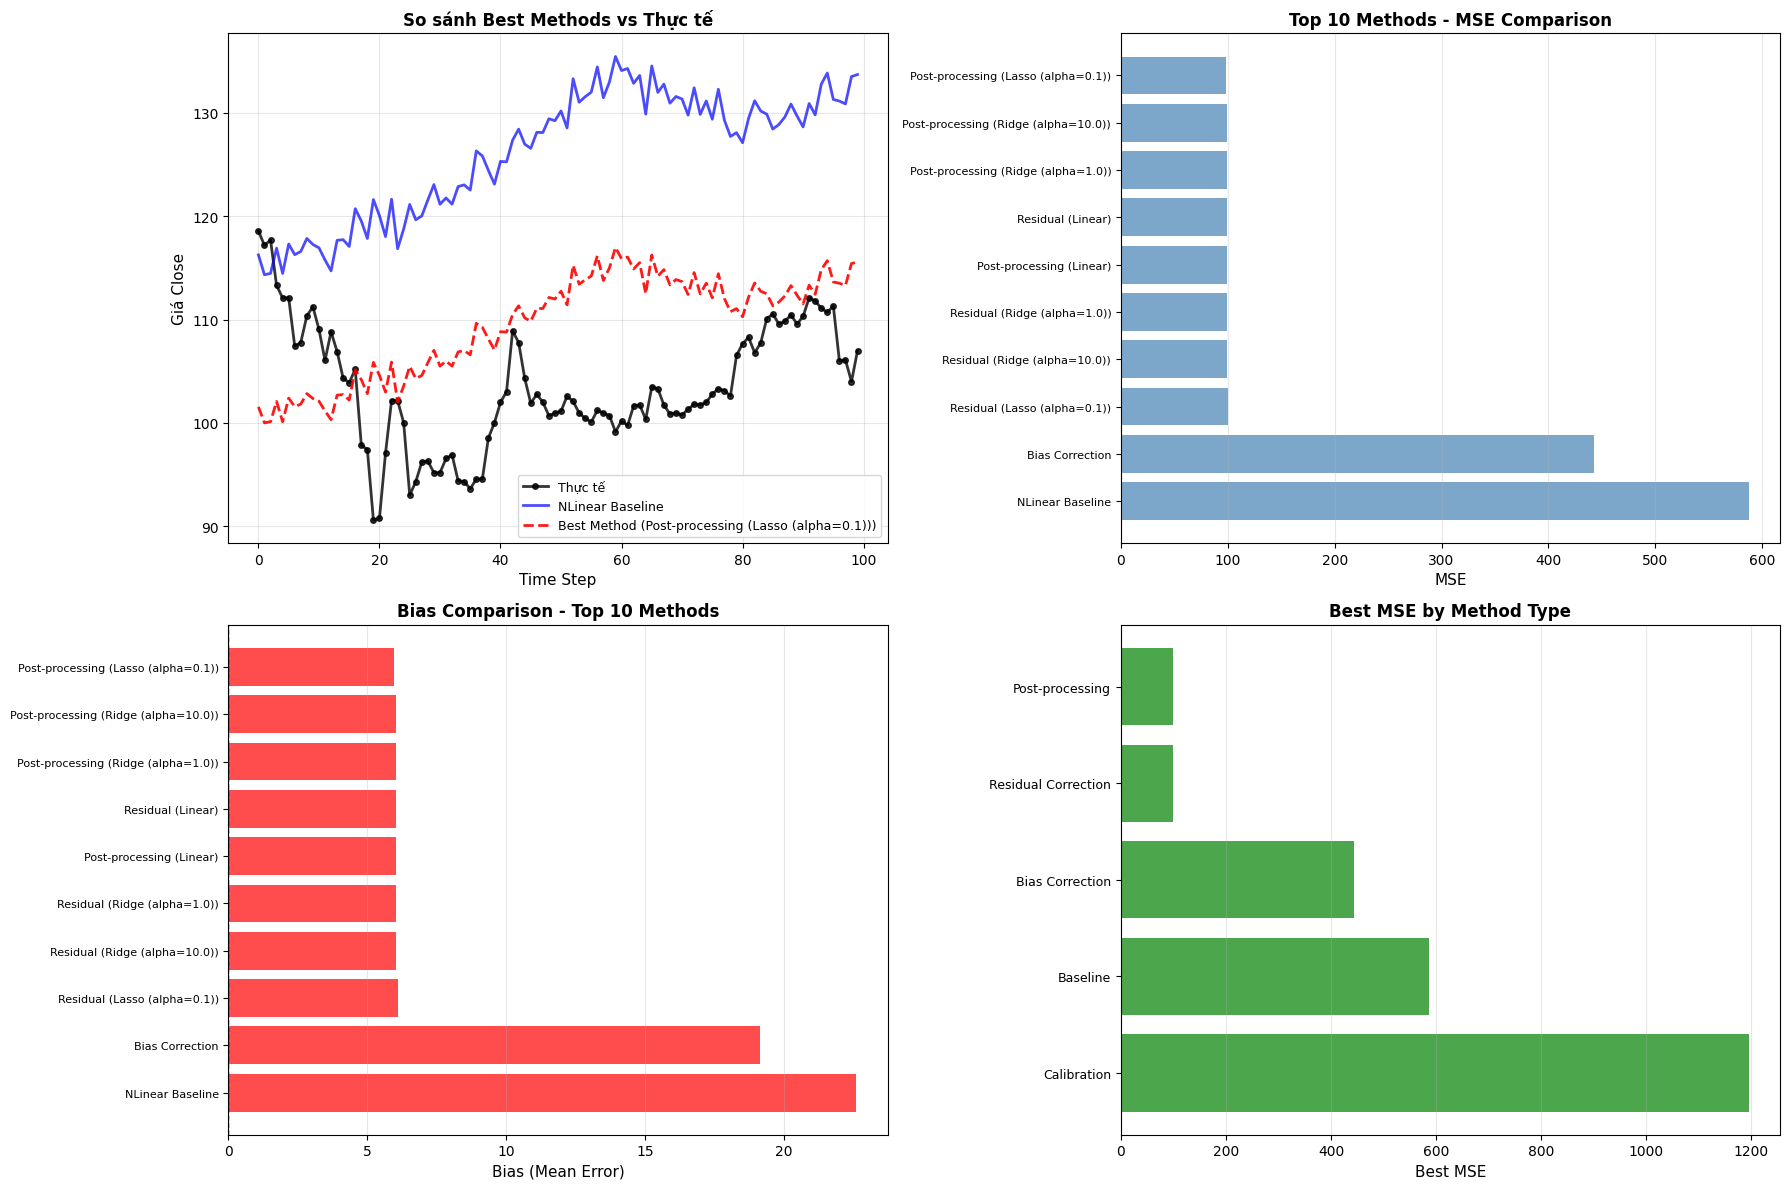

✓ Đã hiển thị biểu đồ so sánh


In [12]:
# Vẽ biểu đồ so sánh best methods
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Predictions vs Actual
ax1 = axes[0, 0]
x_axis = np.arange(len(y_true))
ax1.plot(x_axis, y_true, 'o-', label='Thực tế', linewidth=2, markersize=4, color='black', alpha=0.8)
ax1.plot(x_axis, pred_nlinear_baseline, '-', label='NLinear Baseline', linewidth=2, alpha=0.7, color='blue')

# Tìm và vẽ best method
best_method_name = best_method['Method']
if 'Bias Correction' in best_method_name:
    best_pred = pred_bias_corrected
elif 'Residual' in best_method_name:
    # Tách method name: tìm text giữa dấu ngoặc đơn đầu tiên và cuối cùng
    start = best_method_name.find('(') + 1
    end = best_method_name.rfind(')')
    method_name = best_method_name[start:end] if start > 0 and end > start else None
    if method_name:
        best_pred = next((r['prediction'] for r in residual_results if r['method'] == method_name), None)
        if best_pred is None:
            best_pred = pred_nlinear_baseline
    else:
        best_pred = pred_nlinear_baseline
elif 'Isotonic' in best_method_name:
    best_pred = pred_isotonic
elif 'Post-processing' in best_method_name:
    # Tách method name: tìm text giữa dấu ngoặc đơn đầu tiên và cuối cùng
    start = best_method_name.find('(') + 1
    end = best_method_name.rfind(')')
    method_name = best_method_name[start:end] if start > 0 and end > start else None
    if method_name:
        best_pred = next((r['prediction'] for r in post_results if r['method'] == method_name), None)
        if best_pred is None:
            best_pred = pred_nlinear_baseline
    else:
        best_pred = pred_nlinear_baseline
else:
    best_pred = pred_nlinear_baseline

ax1.plot(x_axis, best_pred, '--', label=f"Best Method ({best_method_name})", 
         linewidth=2, alpha=0.9, color='red')

ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Giá Close', fontsize=11)
ax1.set_title('So sánh Best Methods vs Thực tế', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: MSE comparison
ax2 = axes[0, 1]
top_10 = comparison_df.head(10)
ax2.barh(range(len(top_10)), top_10['MSE'].values, color='steelblue', alpha=0.7)
ax2.set_yticks(range(len(top_10)))
ax2.set_yticklabels(top_10['Method'].values, fontsize=8)
ax2.set_xlabel('MSE', fontsize=11)
ax2.set_title('Top 10 Methods - MSE Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()

# Plot 3: Bias comparison
ax3 = axes[1, 0]
top_10_bias = comparison_df.head(10)
colors_bias = ['red' if b > 0 else 'green' for b in top_10_bias['Bias'].values]
ax3.barh(range(len(top_10_bias)), top_10_bias['Bias'].values, color=colors_bias, alpha=0.7)
ax3.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax3.set_yticks(range(len(top_10_bias)))
ax3.set_yticklabels(top_10_bias['Method'].values, fontsize=8)
ax3.set_xlabel('Bias (Mean Error)', fontsize=11)
ax3.set_title('Bias Comparison - Top 10 Methods', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# Plot 4: Methods by Type
ax4 = axes[1, 1]
type_summary = comparison_df.groupby('Type')['MSE'].min().sort_values()
ax4.barh(range(len(type_summary)), type_summary.values, color='green', alpha=0.7)
ax4.set_yticks(range(len(type_summary)))
ax4.set_yticklabels(type_summary.index.values, fontsize=9)
ax4.set_xlabel('Best MSE', fontsize=11)
ax4.set_title('Best MSE by Method Type', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

print("✓ Đã hiển thị biểu đồ so sánh")


## 11. Tổng Kết và Kết Luận


In [13]:
print("="*70)
print("📊 TỔNG KẾT VÀ KẾT LUẬN")
print("="*70)

print(f"\n🎯 KẾT QUẢ NGHIÊN CỨU:")
print(f"   - Số phương pháp đã thử: {len(comparison_df)}")
print(f"   - Baseline (NLinear): MSE = {baseline_method['MSE']:.4f}, Bias = {baseline_method['Bias']:.4f}")
print(f"   - Best Method: {best_method['Method']}")
print(f"   - Best MSE: {best_method['MSE']:.4f}")
print(f"   - Best Bias: {best_method['Bias']:.4f}")
print(f"   - Cải thiện MSE: {improvement:+.2f}%")

print(f"\n📈 PHÂN TÍCH THEO TYPE:")
for method_type in comparison_df['Type'].unique():
    type_df = comparison_df[comparison_df['Type'] == method_type]
    best_in_type = type_df.iloc[0]
    print(f"   - {method_type}: {best_in_type['Method']} (MSE: {best_in_type['MSE']:.4f})")

print(f"\n💡 KẾT LUẬN:")
if improvement > 0:
    print(f"   ✓ Phương pháp {best_method['Method']} cải thiện được {improvement:.2f}% so với baseline")
    print(f"   ✓ Bias đã được giảm từ {baseline_method['Bias']:.4f} xuống {best_method['Bias']:.4f}")
    print(f"   ✓ Nên sử dụng: {best_method['Method']} cho submission")
else:
    print(f"   ⚠️  Không có phương pháp nào cải thiện so với baseline")
    print(f"   ⚠️  Có thể cần thử các phương pháp khác hoặc tối ưu hyperparameters")

print(f"\n✓ Hoàn thành nghiên cứu bias correction methods!")


📊 TỔNG KẾT VÀ KẾT LUẬN

🎯 KẾT QUẢ NGHIÊN CỨU:
   - Số phương pháp đã thử: 11
   - Baseline (NLinear): MSE = 587.3829, Bias = 22.5906
   - Best Method: Post-processing (Lasso (alpha=0.1))
   - Best MSE: 98.4802
   - Best Bias: 5.9729
   - Cải thiện MSE: +83.23%

📈 PHÂN TÍCH THEO TYPE:
   - Post-processing: Post-processing (Lasso (alpha=0.1)) (MSE: 98.4802)
   - Residual Correction: Residual (Linear) (MSE: 99.2647)
   - Bias Correction: Bias Correction (MSE: 443.0892)
   - Baseline: NLinear Baseline (MSE: 587.3829)
   - Calibration: Isotonic Calibration (MSE: 1195.0570)

💡 KẾT LUẬN:
   ✓ Phương pháp Post-processing (Lasso (alpha=0.1)) cải thiện được 83.23% so với baseline
   ✓ Bias đã được giảm từ 22.5906 xuống 5.9729
   ✓ Nên sử dụng: Post-processing (Lasso (alpha=0.1)) cho submission

✓ Hoàn thành nghiên cứu bias correction methods!


## 12. Xuất File Submission

Xuất file submission với predictions từ phương pháp tốt nhất đã tìm được.


In [14]:
print("="*70)
print("💾 XUẤT FILE SUBMISSION")
print("="*70)

# Xác định best method và lấy predictions tương ứng
best_method_name = best_method['Method']

print(f"\n📊 Sử dụng phương pháp: {best_method_name}")
print(f"   - MSE: {best_method['MSE']:.4f}")
print(f"   - Bias: {best_method['Bias']:.4f}")

# Lấy predictions từ best method
if 'Bias Correction' in best_method_name:
    final_predictions = pred_bias_corrected
    method_suffix = "bias_correction"
elif 'Residual' in best_method_name:
    # Tách method name: tìm text giữa dấu ngoặc đơn đầu tiên và cuối cùng
    start = best_method_name.find('(') + 1
    end = best_method_name.rfind(')')
    method_name = best_method_name[start:end] if start > 0 and end > start else None
    if method_name:
        final_predictions = next((r['prediction'] for r in residual_results if r['method'] == method_name), None)
        if final_predictions is None:
            final_predictions = pred_nlinear_baseline
            method_suffix = "baseline"
            print("   ⚠️  Không tìm thấy residual method, sử dụng baseline")
        else:
            method_suffix = f"residual_{method_name.lower().replace(' ', '_')}"
    else:
        final_predictions = pred_nlinear_baseline
        method_suffix = "baseline"
        print("   ⚠️  Không parse được method name, sử dụng baseline")
elif 'Isotonic' in best_method_name:
    final_predictions = pred_isotonic
    method_suffix = "isotonic"
elif 'Post-processing' in best_method_name:
    # Tách method name: tìm text giữa dấu ngoặc đơn đầu tiên và cuối cùng
    start = best_method_name.find('(') + 1
    end = best_method_name.rfind(')')
    method_name = best_method_name[start:end] if start > 0 and end > start else None
    if method_name:
        final_predictions = next((r['prediction'] for r in post_results if r['method'] == method_name), None)
        if final_predictions is None:
            final_predictions = pred_nlinear_baseline
            method_suffix = "baseline"
            print("   ⚠️  Không tìm thấy post-processing method, sử dụng baseline")
        else:
            method_suffix = f"postprocessing_{method_name.lower().replace(' ', '_')}"
    else:
        final_predictions = pred_nlinear_baseline
        method_suffix = "baseline"
        print("   ⚠️  Không parse được method name, sử dụng baseline")
else:
    # Fallback: dùng baseline
    final_predictions = pred_nlinear_baseline
    method_suffix = "baseline"
    print("   ⚠️  Sử dụng baseline vì không tìm thấy best method")

# Đảm bảo có đủ 100 predictions
if len(final_predictions) < horizon:
    print(f"\n⚠️  Chỉ có {len(final_predictions)} predictions, cần {horizon}")
    # Pad với giá trị cuối cùng nếu thiếu
    final_predictions = np.pad(final_predictions, (0, horizon - len(final_predictions)), mode='edge')
    print(f"   ✓ Đã pad lên {len(final_predictions)} predictions")
elif len(final_predictions) > horizon:
    final_predictions = final_predictions[:horizon]
    print(f"\n⚠️  Có {len(final_predictions)} predictions, chỉ lấy {horizon} đầu tiên")

# Đảm bảo không có giá trị âm hoặc NaN
final_predictions = np.maximum(final_predictions, 0)  # Không cho giá trị âm
if np.isnan(final_predictions).any():
    print("   ⚠️  Phát hiện NaN, thay thế bằng giá trị trung bình")
    final_predictions = np.nan_to_num(final_predictions, nan=np.nanmean(final_predictions))

# Tạo submission file theo format sample_submission.csv
# Format: id (1-100), close (giá trị số)
submission = pd.DataFrame({
    "id": np.arange(1, horizon + 1),  # id từ 1 đến 100
    "close": final_predictions
})

# Validation: Kiểm tra format
assert len(submission) == horizon, f"Số dòng phải là {horizon}, nhưng có {len(submission)}"
assert list(submission.columns) == ["id", "close"], f"Columns phải là ['id', 'close'], nhưng có {list(submission.columns)}"
assert submission["id"].min() == 1, f"id phải bắt đầu từ 1, nhưng min là {submission['id'].min()}"
assert submission["id"].max() == horizon, f"id phải kết thúc ở {horizon}, nhưng max là {submission['id'].max()}"
assert not submission["close"].isna().any(), "Không được có NaN trong cột close"
assert (submission["close"] >= 0).all(), "Giá trị close không được âm"

# Tên file submission
submission_file = f"submission_nlinear_{method_suffix}.csv"
submission.to_csv(submission_file, index=False)

# Kiểm tra format với sample_submission.csv nếu có
try:
    sample = pd.read_csv("sample_submission.csv")
    print(f"\n✓ Đã kiểm tra với sample_submission.csv:")
    print(f"   - Sample columns: {list(sample.columns)}")
    print(f"   - Submission columns: {list(submission.columns)}")
    print(f"   - Sample shape: {sample.shape}")
    print(f"   - Submission shape: {submission.shape}")
    if list(sample.columns) == list(submission.columns):
        print(f"   ✓ Columns khớp với sample!")
    else:
        print(f"   ⚠️  Columns không khớp!")
except FileNotFoundError:
    print(f"\n⚠️  Không tìm thấy sample_submission.csv để so sánh")
except Exception as e:
    print(f"\n⚠️  Lỗi khi đọc sample_submission.csv: {e}")

print(f"\n✓ Đã tạo submission file: {submission_file}")
print(f"   - Shape: {submission.shape}")
print(f"   - Columns: {list(submission.columns)}")

print(f"\n📊 Thống kê predictions:")
print(f"   - Min: {final_predictions.min():.2f}")
print(f"   - Max: {final_predictions.max():.2f}")
print(f"   - Mean: {final_predictions.mean():.2f}")
print(f"   - Std: {final_predictions.std():.2f}")
print(f"   - Median: {np.median(final_predictions):.2f}")

print(f"\n📅 10 dòng đầu:")
print(submission.head(10).to_string(index=False))
print(f"\n📅 10 dòng cuối:")
print(submission.tail(10).to_string(index=False))

# So sánh với baseline nếu có
if 'pred_nlinear_baseline' in globals():
    baseline_mean = np.mean(pred_nlinear_baseline[:len(final_predictions)])
    final_mean = np.mean(final_predictions)
    diff = final_mean - baseline_mean
    print(f"\n📊 So sánh với Baseline:")
    print(f"   - Baseline mean: {baseline_mean:.2f}")
    print(f"   - Final mean: {final_mean:.2f}")
    print(f"   - Chênh lệch: {diff:+.2f} ({diff/baseline_mean*100:+.2f}%)")

print(f"\n✅ Hoàn thành xuất file submission!")


💾 XUẤT FILE SUBMISSION

📊 Sử dụng phương pháp: Post-processing (Lasso (alpha=0.1))
   - MSE: 98.4802
   - Bias: 5.9729

⚠️  Không tìm thấy sample_submission.csv để so sánh

✓ Đã tạo submission file: submission_nlinear_postprocessing_lasso_(alpha=0.1).csv
   - Shape: (100, 2)
   - Columns: ['id', 'close']

📊 Thống kê predictions:
   - Min: 100.02
   - Max: 116.97
   - Mean: 109.46
   - Std: 4.91
   - Median: 111.20

📅 10 dòng đầu:
 id      close
  1 101.561661
  2 100.017593
  3 100.127762
  4 102.082962
  5 100.121658
  6 102.405640
  7 101.580292
  8 101.826630
  9 102.839645
 10 102.368454

📅 10 dòng cuối:
 id      close
 91 111.500458
 92 113.319839
 93 112.439377
 94 114.808701
 95 115.686432
 96 113.633499
 97 113.507568
 98 113.287811
 99 115.409576
100 115.569077

📊 So sánh với Baseline:
   - Baseline mean: 126.08
   - Final mean: 109.46
   - Chênh lệch: -16.62 (-13.18%)

✅ Hoàn thành xuất file submission!
